# Trabalho Mineração de Dados - Grupo 4
**Curso:** Ciência de Dados e IA — PUC Campinas   
**Integrante 1:** Camila Parreira Gonçalves Oliveira (RA: 26007411)   
**Integrante 2:** Rafael Canezella (RA: 26005054)
<br>**Integrante 3:** Pietro Felipe Souto Xavier (RA: 26019598)
<br>**Integrante 4:** Thais Rodrigues Pampado de Carvalho (RA: 26008585)

---
## Etapa 1 — Importando a biblioteca

In [ ]:
import numpy as np
import pandas as pd
import scipy as sc

In [ ]:
df = pd.read_csv("/content/supermarket.csv")
df

,department1,department2,department3,department4,department5,department6,department7,department8,department9,grocery misc,...,department208,department209,department210,department211,department212,department213,department214,department215,department216,total
0,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,high
1,t,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
2,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
3,t,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4623,?,?,?,t,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,high
4624,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4625,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


---
## Etapa 2 — Removendo as Colunas Department

In [ ]:
# para obter o número de colunas (217)
print("Tamanho original:", df.shape)

department_cols = []

for col in df.columns:
  if col.startswith('department'):
    department_cols.append(col)

print(f"\nColunas department encontradas: {len(department_cols)}") #mostra que há 111 colunas com department
print(department_cols[:10], "...") #mostra os 10 primeiros departaments

#tira as colunas department
df_without_departments = df.drop(department_cols, axis = 1)
print("\nTamanho após remover departments:", df_without_departments.shape) #mudou para 106 (217-111=106)

df_without_departments

Tamanho original: (4627, 217)

Colunas department encontradas: 111
['department1', 'department2', 'department3', 'department4', 'department5', 'department6', 'department7', 'department8', 'department9', 'department11'] ...

Tamanho após remover departments: (4627, 106)


,grocery misc,baby needs,bread and cake,baking needs,coupons,juice-sat-cord-ms,tea,biscuits,canned fish-meat,canned fruit,...,750ml red nz,750ml white imp,750ml red imp,sparkling nz,sparkling imp,brew kits/accesry,port and sherry,ctrled label wine,non host support,total
0,?,t,t,t,?,t,?,t,?,?,...,?,?,?,?,?,?,?,?,?,high
1,?,?,?,?,?,?,?,?,t,t,...,?,?,?,?,?,?,?,?,?,low
2,?,?,t,t,?,t,?,t,?,t,...,?,?,?,?,?,?,?,?,?,low
3,?,?,t,t,?,t,?,t,?,?,...,?,?,?,?,?,?,?,?,?,low
4,?,?,t,t,?,t,t,?,?,?,...,?,?,?,?,?,?,?,?,?,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,?,?,t,t,?,t,?,t,?,t,...,?,?,?,?,?,?,?,?,?,low
4623,?,?,t,t,?,t,?,t,?,t,...,?,?,?,?,?,?,?,?,?,high
4624,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4625,?,t,?,t,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


---
## Etapa 3 — Remover colunas com suporte = 0 (colunas vazias)

In [ ]:
columns_to_drop = [] #criando uma lista inicialmente vazia para armazenar as colunas que terão que ser retiradas

for col in df_without_departments.columns: #iterando entre todas as colunas
  if (df_without_departments[col].value_counts().get('?', 0) == len(df_without_departments)): #vendo se a quantidade de '?' na coluna é igual ao total de linhas, ou seja, se a coluna está vazia
    print(col)
    columns_to_drop.append(col) #adicionando o nome da coluna na lista se a condição acima for verdade
print(columns_to_drop)

coupons
flowers
health food bulk
brew kits/accesry
ctrled label wine
['coupons', 'flowers', 'health food bulk', 'brew kits/accesry', 'ctrled label wine']


In [ ]:
# limpando a base utilizando a lista criada no loop

supermarket_clean = df_without_departments.drop(columns_to_drop, axis = 1)

supermarket_clean

,grocery misc,baby needs,bread and cake,baking needs,juice-sat-cord-ms,tea,biscuits,canned fish-meat,canned fruit,canned vegetables,...,casks red wine,750ml white nz,750ml red nz,750ml white imp,750ml red imp,sparkling nz,sparkling imp,port and sherry,non host support,total
0,?,t,t,t,t,?,t,?,?,t,...,?,t,?,?,?,?,?,?,?,high
1,?,?,?,?,?,?,?,t,t,t,...,?,?,?,?,?,?,?,?,?,low
2,?,?,t,t,t,?,t,?,t,?,...,?,?,?,?,?,?,?,?,?,low
3,?,?,t,t,t,?,t,?,?,t,...,?,?,?,?,?,?,?,?,?,low
4,?,?,t,t,t,t,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,?,?,t,t,t,?,t,?,t,t,...,?,?,?,?,?,?,?,?,?,low
4623,?,?,t,t,t,?,t,?,t,t,...,?,?,?,?,?,?,?,?,?,high
4624,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4625,?,t,?,t,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


---
## Etapa 4 — Exportando para CSV

In [ ]:
# vendo quantas restantes
print("Colunas restantes:")
print(list(supermarket_clean.columns))
print(f"\nTotal: {supermarket_clean.shape[1]} colunas e {supermarket_clean.shape[0]} linhas")

# exportando para CSV
supermarket_clean.to_csv("supermarket_clean.csv", index=False)

Colunas restantes:
['grocery misc', 'baby needs', 'bread and cake', 'baking needs', 'juice-sat-cord-ms', 'tea', 'biscuits', 'canned fish-meat', 'canned fruit', 'canned vegetables', 'breakfast food', 'cigs-tobacco pkts', 'cigarette cartons', 'cleaners-polishers', 'coffee', 'sauces-gravy-pkle', 'confectionary', 'puddings-deserts', 'dishcloths-scour', 'deod-disinfectant', 'frozen foods', 'razor blades', 'fuels-garden aids', 'spices', 'jams-spreads', 'insecticides', 'pet foods', 'laundry needs', 'party snack foods', 'tissues-paper prd', 'wrapping', 'dried vegetables', 'pkt-canned soup', 'soft drinks', 'health food other', 'beverages hot', 'health&beauty misc', 'deodorants-soap', 'mens toiletries', 'medicines', 'haircare', 'dental needs', 'lotions-creams', 'sanitary pads', 'cough-cold-pain', 'meat misc', 'cheese', 'chickens', 'milk-cream', 'cold-meats', 'deli gourmet', 'margarine', 'salads', 'small goods', 'dairy foods', 'fruit drinks', 'delicatessen misc', 'beef', 'hogget', 'lamb', 'pet fo

---
## Etapa 5 — Regras Fortes, Cenários e Intervenções

###**REGRA 1**

**bread and cake=t vegetables=t 2298 ==> fruit=t 1791    <conf:(0.78)> lift:(1.22) lev:(0.07) [319] conv:(1.63)**

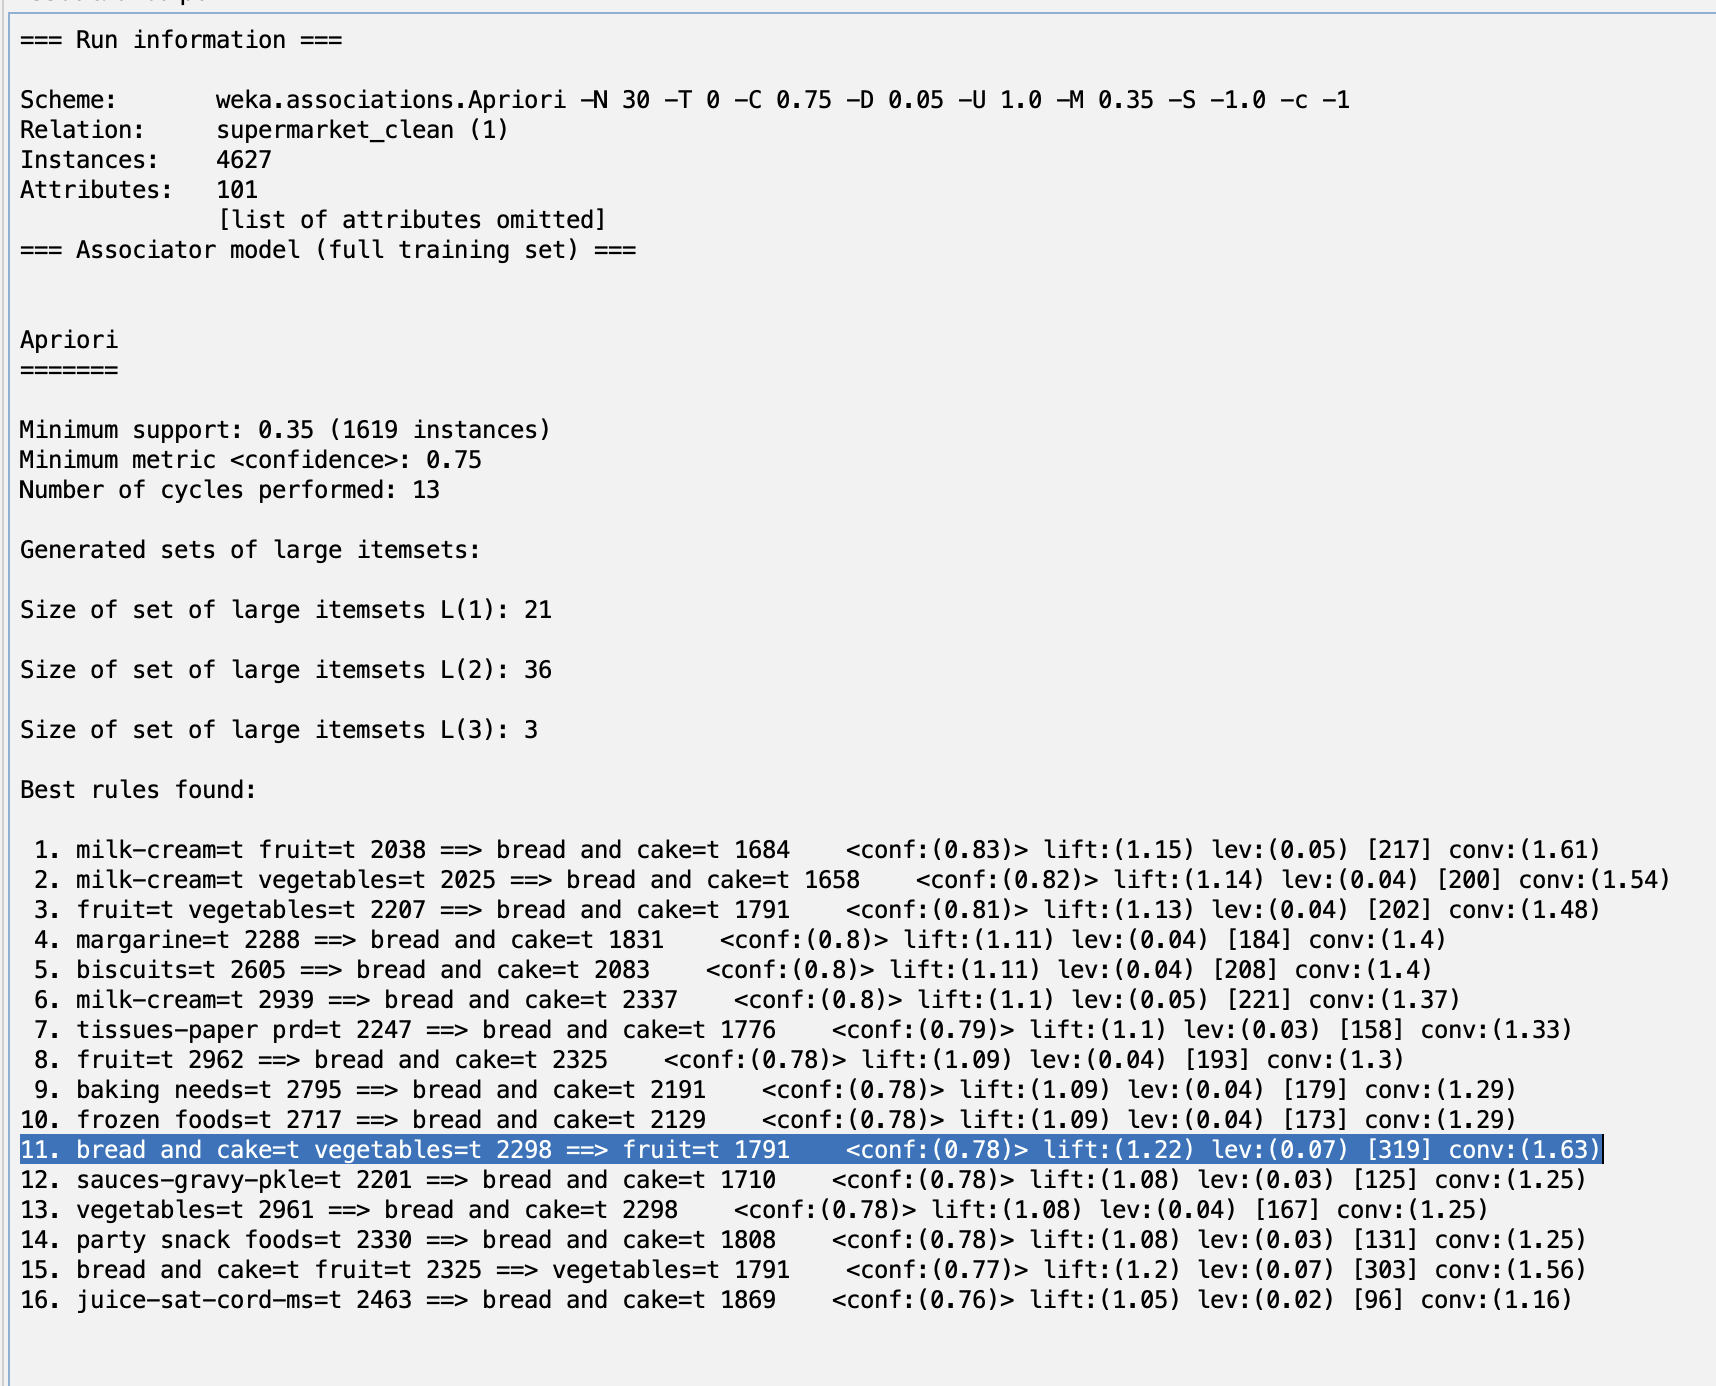

Sup{bread and cake, vegetables, fruit} = 1791 / 4627 = 0.3871
<br>Sup{bread and cake, vegetables} = 2298 / 4627 = 0.4967
<br>Sup{fruit} = 2962 / 4627 = 0.6402
<br>Confiança = 0.78
<br>Lift = 1.22
<br>Leverage = 0.07
<br><br>
**ANÁLISE**

A métrica de **Confiança** de 0.78 indica que, dado que alguém tenha comprado dentro das seções de pães e bolos e vegetais, existe uma chance de 78% dela também comprar na seção frutas. Ou seja, é uma ocorrência frequente dentre os eventos observados.

O valor do **Lift** de 1.22 indica que esta co-ocorrência de eventos acontece 0.22 vezes mais do que o esperado ao acaso, ou seja, implica que existe uma correlação positiva entre a pessoa comprar na seção ‘bread and cake’ e 'vegetables’, e comprar na seção ‘fruits’. Neste caso, como estamos trabalhando com eventos que têm **Suportes** relativamente altos, o lift seria o suficiente para confirmar essa ligação, porém ele é indicado também na métrica **Leverage**, já que o valor é maior que 0, indicando que há uma diferença positiva de 0.07 entre a frequência observada da co-ocorrência em relação à esperada ao acaso.
<br><br>
**CENÁRIO**

A regra reflete um cenário de pessoas que estão buscando uma alimentação saudável. Para café da manhã/lanche da tarde, elas compram itens como pães (seção ‘bread and cake’) e frutas (seção ‘fruits’), e vegetais (seção ‘vegetables’) para almoço/jantar.
<br><br>
**INTERVENÇÃO**

“Campanha da Dieta Saudável” - Uma ação em que, ao comprar pelo menos 1 item de cada um dos setores [bread and cake, vegetables, fruits], o cliente ganha um livro (ou acesso a um QR Code que direciona a um livro, para diminuir custos) de receitas saudáveis. Para o cliente, que está buscando uma alimentação saudável, é um brinde que ajuda na sua meta e que pode ajudá-lo a conhecer novos pratos gostosos para experimentar. Para o supermercado, pode ajudar a incentivar vendas de outros produtos a partir do momento em que o cliente decidir fazer uma receita que precisa de outros ingredientes além daqueles que ele comprou.


###**REGRA 2**

**bread and cake=t sauces-gravy-pkle=t party snack foods=t 1062 ==> total=high 708    conf:(0.67) < lift:(1.84)> lev:(0.07) [322] conv:(1.91)**

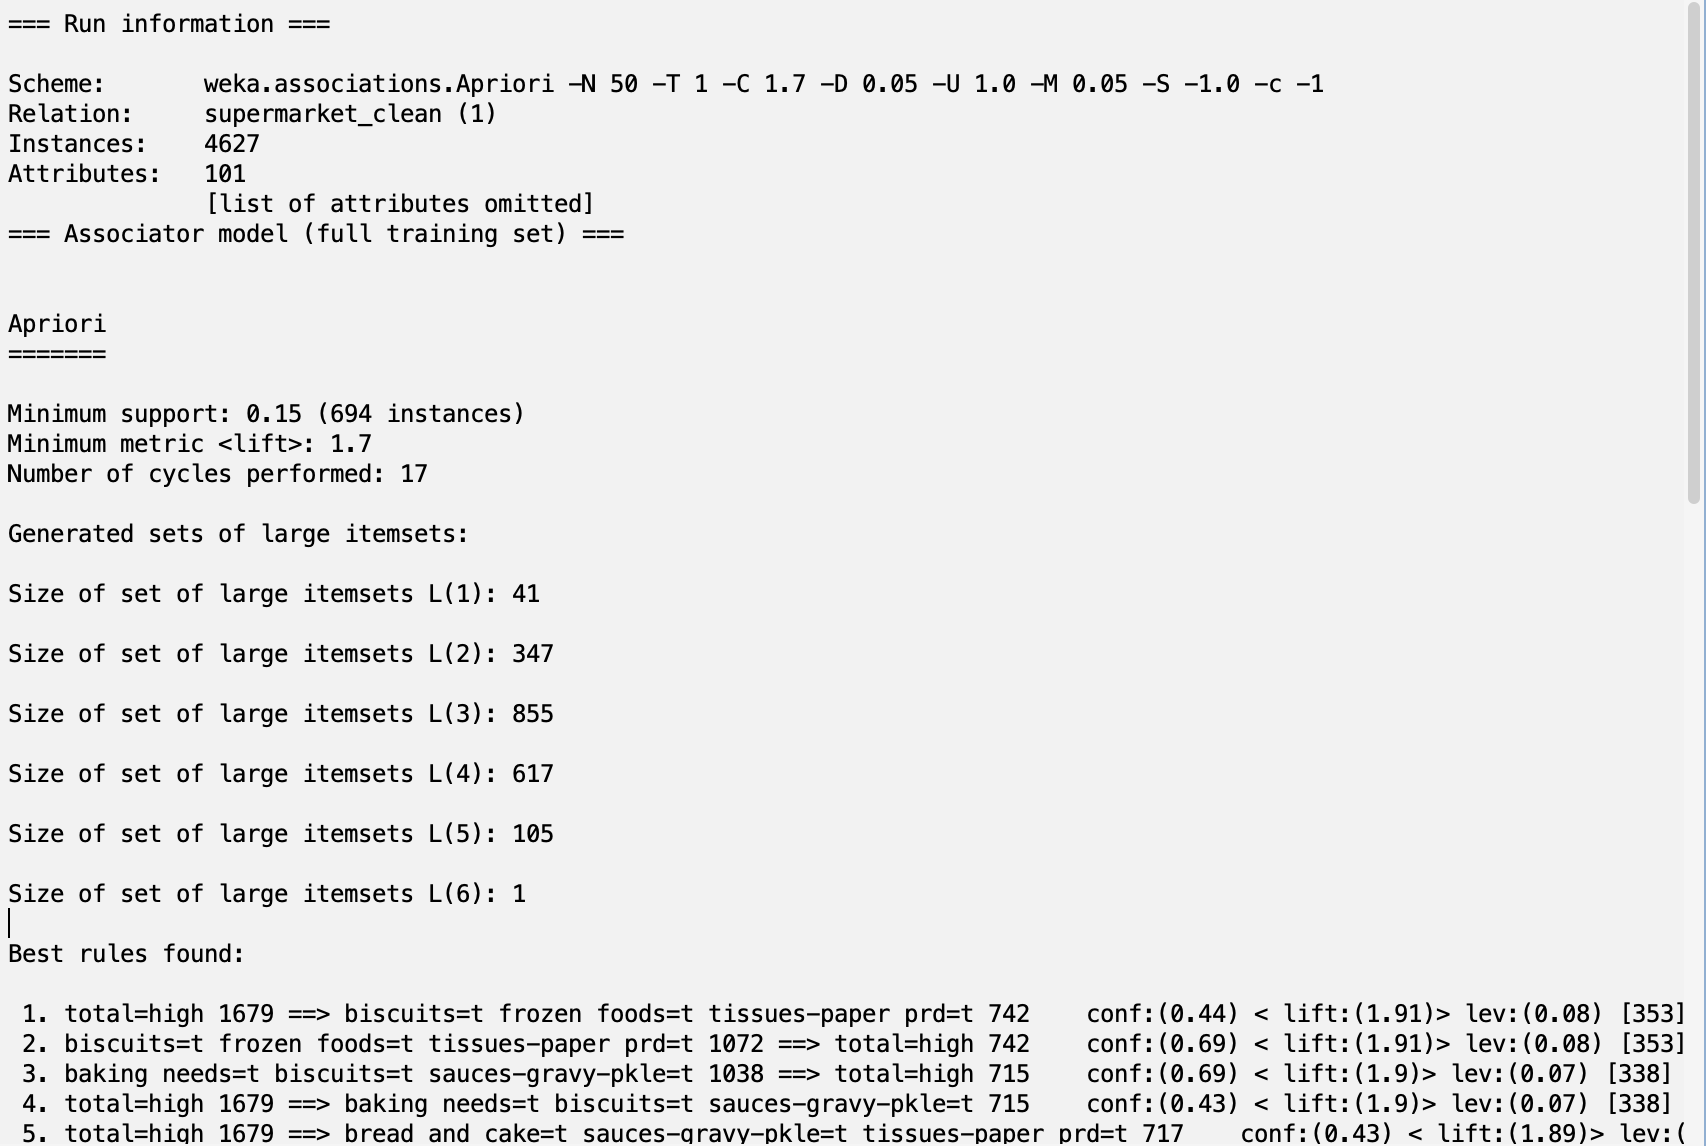

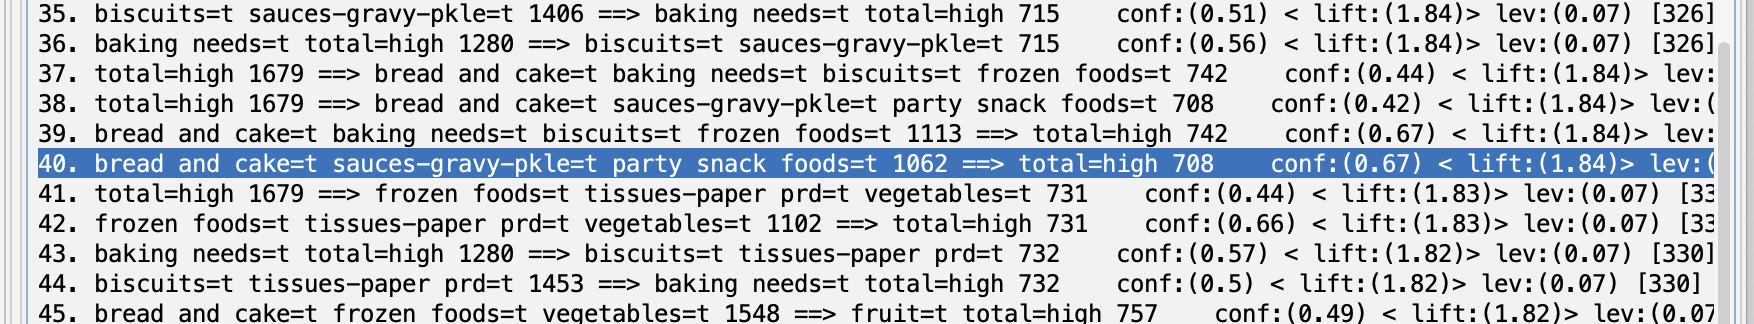


Sup{bread and cake, sauces-gravy-pkle, party snack foods, total high} = 708 / 4627  = 0.1530
<br>Sup{bread and cake, sauces-gravy-pkle, party snack foods} = 1062 / 4627 = 0.2295
<br>Sup{total high} = 1679 / 4627 = 0.3629
<br>Confiança =  0.67
<br>Lift = 1.84
<br>Leverage = 0.07
<br><br>
**ANÁLISE**

Nesta regra, a **Confiança** de 0.67 indica que, dado que um cliente tenha comprado nas seções ‘bread and cake’, ‘sauces-gravy-pkle’, e ‘party snack foods’, existe uma chance de 67% de seu carrinho ter um valor alto. Isto é mais da metade dos clientes que compram nesse conjunto de seções, o que torna essa regra interessante pensando na possibilidade de ações segmentadas.

Ainda, o **Lift** de 1.84 indica que estes eventos se influenciam fortemente, já que a co-ocorrência observada é 0.84 vezes maior do que seria a frequência esperada se eles fossem independentes.

Neste caso, como os **Suportes** dos eventos individuais são relativamente baixos, o fato de o **Leverage** ser 0.07 confirma que os eventos possuem uma relação de influência positiva de fato.
<br><br>
**CENÁRIO**

As pessoas que compram nestas seções (bread and cake, sauces-gravy-pkle, party snack foods) são aquelas que costumam receber os amigos em casa. Essas reuniões costumam incluir comidinhas que poderiam ser encontradas nas seções de pães e bolos (pãezinhos pra cachorro quente, por exemplo), na seção de molhos (mostarda, ketchup, dipping sauce, etc), além da seção de aperitivos de festa (salgadinhos, nachos, etc). Como são vários amigos se reunindo e é preciso comprar comidinhas para todo mundo, o valor total do carrinho das pessoas fazendo essas compras fica alto.
<br><br>
**INTERVENÇÃO**

Sabendo que estes clientes tendem a gastar mais e que a Copa do Mundo, que costuma promover várias reuniões e encontros de amigos para assistir aos jogos e favorece este tipo de ocorrência, está chegando, o mercado poderia incentivar estes clientes a realizar mais compras colocando uma promoção estratégica vinculada às partidas do Brasil (por exemplo, em semana de jogo da seleção os produtos dessas seções tem um determinado desconto).

Ou, então, caso o mercado tivesse o conhecimento dos itens específicos que estão mais presentes nestes carrinhos, poderiam fazer um trabalho de PDV que junte esses produtos em um único display para facilitar a jornada de compra, aumentar as vendas e consequentemente o faturamento, trabalhando uma campanha (Ex: “Para torcer com os amigos”) que esteja alinhada com o perfil do cliente que gosta de reunir os amigos em casa.

###**REGRA 3**

**margarine=t 2288 ==> baking needs=t 1645    conf:(0.72) < lift:(1.19)> lev:(0.06) [262] conv:(1.41)**

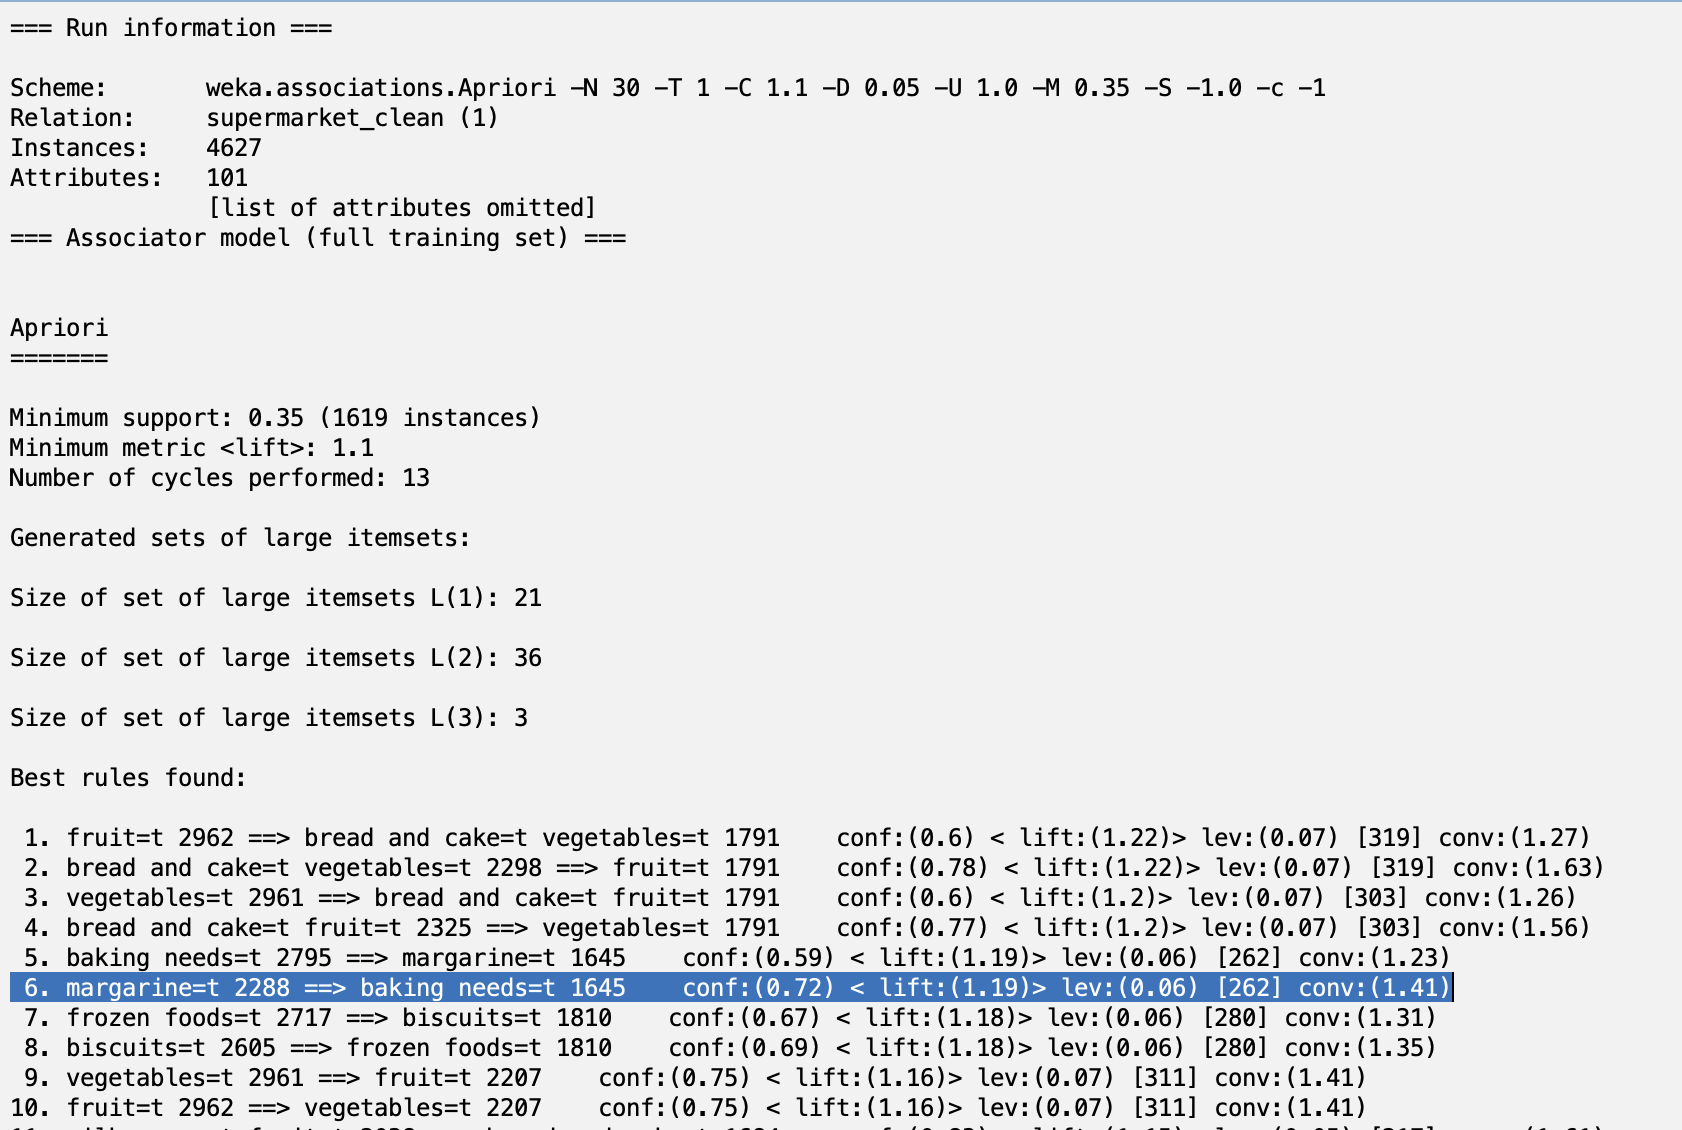


Sup{margarine, baking needs} = 1645 / 4627 = 0.3555
<br>Sup{margarine} = 2288 / 4627 = 0.4897
<br>Sup{baking needs} = 2795 / 4627 = 0.6041
<br>Confiança =  0.72
<br>Lift = 1.19
<br>Leverage = 0.06
<br><br>
**ANÁLISE**

Nesta regra, os eventos possuem um **Suporte** alto, o que a torna interessante por indicar um volume significativo de ocorrências.

A **Confiança** de 0.72 indica que, dado que um cliente comprou na seção ‘margarine’, existe uma chance de 72% de ele também comprar na seção ‘baking needs’. Isso representa uma probabilidade alta, mostrando um possível padrão consistente de consumo entre esses itens.

O **Lift** de 1.19 indica que esses produtos possuem uma associação positiva, ou seja, a co-ocorrência entre eles é 19% maior do que seria esperado caso fossem independentes. Isso reforça que há uma relação relevante entre estas seções.

Além disso, o **Leverage** de 0.06 confirma que essa combinação ocorre com uma frequência significativamente maior do que o acaso, validando que existe uma influência real entre as seções.
<br><br>
**CENÁRIO**

Os clientes que compram na seção ‘margarine’ (margarina) e produtos de ‘baking needs’ (como farinha, fermento, misturas para bolo, etc.) geralmente tem interesse em confeitaria ou panificação, seja profissionalmente ou como hobby, e estão comprando os ingredientes necessários para fazer coisas como bolos, pães doces, etc.
<br><br>
**INTERVENÇÃO**

Sabendo que esses clientes possuem uma tendência de comprar destas seções em conjunto, o mercado pode explorar estratégias de venda combinada. Por exemplo, criar promoções que incluam itens da seção ‘margarine’ e itens de ‘baking needs’ com descontos progressivos, para incentivar ainda mais esse comportamento.

Além disso, ações como agrupar esses produtos em uma mesma área ou criar ilhas temáticas (ex: “Prepare o bolo de aniversário dos sonhos”) podem facilitar a jornada de compra.